# Projet de Détection de Véhicules Non Supervisée
L'objectif de ce projet est de détecter des véhicules sur des images de vidéosurveillance sans utiliser de modèle pré-entraîné. Nous utilisons une approche classique de vision par ordinateur pour analyser les images et isoler les éléments en mouvement.

Le processus se divise en deux grandes étapes. Nous trions d'abord les images par angle de vue à l'aide d'un réseau de neurones. Nous appliquons ensuite des méthodes mathématiques de traitement d'image pour repérer les véhicules dans chaque groupe de caméras

In [1]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from google.colab.patches import cv2_imshow

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm

!pip install kneed -q
from kneed import KneeLocator

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import zipfile
# import requests

# # 1. Configuration du lien Roboflow (PKLot Dataset)
# # Note : C'est le lien direct vers l'archive ZIP du dataset au format CSV/Voc
# url = "https://public.roboflow.com/ds/8u5M68sN0F?key=fXN9O2zVnS" # Lien généré pour PKLot v2
# dataset_zip = "pklot_dataset.zip"
# extract_path = "/content/pklot_data"

# # 2. Téléchargement du fichier
# print("Téléchargement du dataset PKLot...")
# response = requests.get(url, stream=True)
# total_size = int(response.headers.get('content-length', 0))

# with open(dataset_zip, "wb") as f, tqdm(
#     desc=dataset_zip,
#     total=total_size,
#     unit='iB',
#     unit_scale=True,
#     unit_divisor=1024,
# ) as bar:
#     for data in response.iter_content(chunk_size=1024):
#         size = f.write(data)
#         bar.update(size)

# # 3. Extraction du ZIP
# print("\nExtraction des fichiers...")
# if not os.path.exists(extract_path):
#     os.makedirs(extract_path)

# with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# # 4. Mise à jour des chemins pour la suite du notebook
# path_images = os.path.join(extract_path, "train") # Ou le dossier contenant les JPG
# ann_path = os.path.join(path_images, "_annotations.csv")

# print(f"✅ Dataset prêt dans : {path_images}")
# print(f"Fichier d'annotations : {ann_path}")

# # Nettoyage du fichier ZIP pour libérer de l'espace
# os.remove(dataset_zip)

# Chargement et Normalisation des Données
Nous chargeons les images en niveaux de gris pour simplifier l'analyse. L'éclairage varie énormément d'une image à l'autre en fonction de la météo ou de l'heure de la journée.

Nous calculons la luminosité moyenne de tout le jeu de données et nous ajustons chaque image pour qu'elle corresponde à cette moyenne globale. Cette étape est indispensable pour que nos algorithmes ne confondent pas un changement de lumière naturel avec un objet en mouvement.

In [2]:
path_images = '/content/drive/MyDrive/test'
ann_path = os.path.join(path_images, '_annotations.csv')

df = pd.read_csv(ann_path)
labels = {}
for _, row in df.iterrows():
    name = row['filename']
    if name not in labels:
        labels[name] = []
    labels[name].append({
        'class': row['class'],
        'bbox': [row['xmin'], row['ymin'], row['xmax'], row['ymax']]
    })

raw_img_list = []
filenames = sorted([f for f in os.listdir(path_images) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

for f in filenames:
    img_bgr = cv2.imread(os.path.join(path_images, f))
    if img_bgr is not None:
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        raw_img_list.append(gray)

all_raw_imgs = np.array(raw_img_list)

mean_per_img = np.mean(all_raw_imgs, axis=(1, 2), keepdims=True)
mean_global = np.mean(all_raw_imgs)
all_raw_imgs = all_raw_imgs - mean_per_img + mean_global
all_raw_imgs = np.clip(all_raw_imgs, 0, 255).astype(np.uint8)

# Binarisation avec l'Algorithme d'Otsu
Nous devons isoler les objets saillants de l'arrière-plan. Nous utilisons l'algorithme d'Otsu disponible dans la bibliothèque de traitement d'image OpenCV.

Cet algorithme analyse l'ensemble des pixels de notre base de données. Il calcule le seuil mathématique exact pour transformer les images en noir et blanc pur. Le résultat élimine les nuances de gris inutiles et met en évidence les formes principales.

In [ ]:
def display_global_otsu_comparison(raw_np, bin_np, filenames, labels_dict, n=3, label=True):
    for _ in range(n):
        idx = random.randint(0, len(filenames) - 1)
        name = filenames[idx]
        before_img = cv2.cvtColor(raw_np[idx], cv2.COLOR_GRAY2BGR)
        after_img = cv2.cvtColor(bin_np[idx], cv2.COLOR_GRAY2BGR)

        if label and name in labels_dict:
            for obj in labels_dict[name]:
                x1, y1, x2, y2 = map(int, obj['bbox'])
                for img in [before_img, after_img]:
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(img, obj['class'], (x1, y1 - 10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        comparison = np.hstack((before_img, after_img))
        cv2_imshow(cv2.resize(comparison, (1024, 512)))

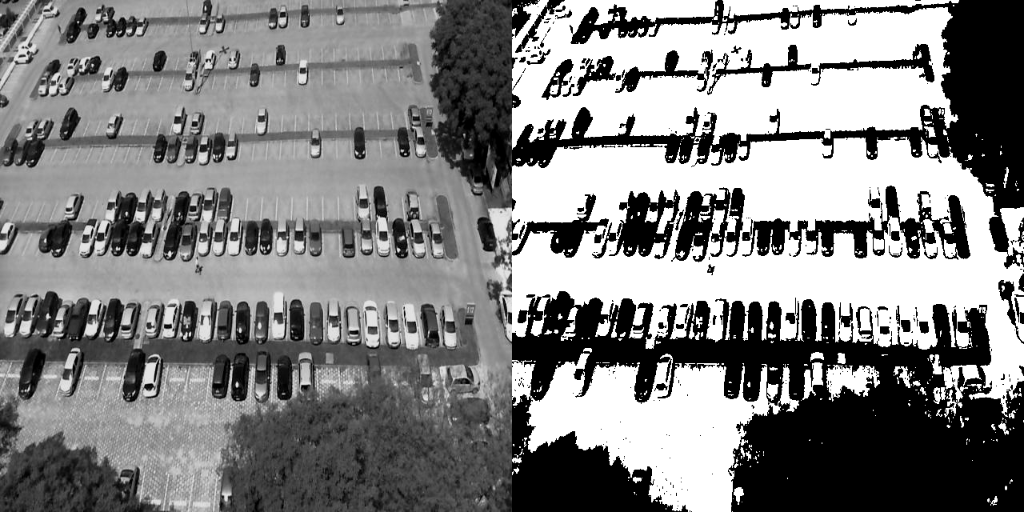

In [3]:
all_pixels = all_raw_imgs.flatten()
global_threshold, _ = cv2.threshold(all_pixels, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

img_binarized = np.where(all_raw_imgs > global_threshold, 255, 0).astype(np.uint8)

display_global_otsu_comparison(all_raw_imgs, img_binarized, filenames, labels, n=1, label=False)

# Tri des Caméras par Apprentissage Profond
Notre jeu de données contient des images provenant de plusieurs caméras mélangées. Pour détecter un mouvement de manière fiable, nous devons comparer des images prises depuis le même point de vue.

Nous configurons un Auto-encodeur avec la bibliothèque PyTorch. Ce réseau de neurones apprend à compresser chaque image en un format mathématique très réduit. Ce processus ignore les petits éléments mobiles de la route et se concentre uniquement sur la structure géométrique du décor.

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * 32 * 32, latent_dim)
        )
        self.decoder_input = nn.Linear(latent_dim, 32 * 32 * 32)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        x = self.decoder_input(latent).view(-1, 32, 32, 32)
        x = self.decoder(x)
        return x, latent

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder(latent_dim=64).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

target_size = (128, 128)
img_resized = np.array([cv2.resize(im, target_size) for im in img_binarized])
X_tensor = torch.FloatTensor(img_resized).unsqueeze(1) / 255.0
dataset = TensorDataset(X_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

model.train()
epochs = 20
pbar_epochs = tqdm(range(epochs), desc="Entraînement de l'Auto-encodeur")

for epoch in pbar_epochs:
    running_loss = 0.0
    for (data,) in loader:
        data = data.to(device)
        optimizer.zero_grad()
        output, _ = model(data)
        loss = criterion(output, data)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    pbar_epochs.set_postfix({'loss': f"{running_loss/len(loader):.4f}"})

Entraînement de l'Auto-encodeur:   0%|          | 0/20 [00:00<?, ?it/s]

# Regroupement Automatique des Vues
Le réseau de neurones a terminé l'analyse géométrique. Nous utilisons un algorithme de clustering pour rassembler les images ayant une structure similaire.

La méthode mathématique du coude calcule de façon autonome le nombre optimal de caméras à isoler. L'algorithme hiérarchique place ensuite chaque image dans le groupe qui correspond précisément à son angle de vue d'origine.

Extraction des signatures:   0%|          | 0/39 [00:00<?, ?it/s]

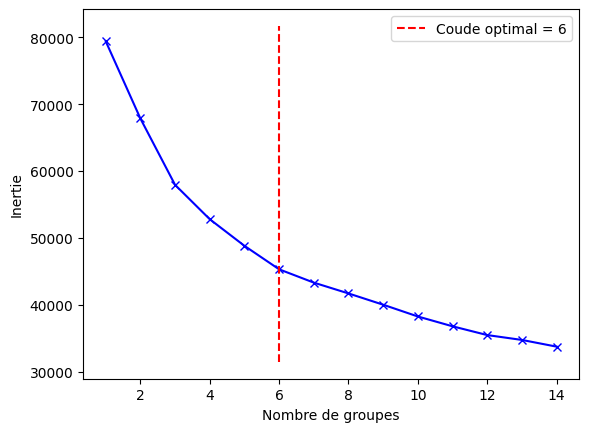

In [7]:
model.eval()
latents_list = []
eval_loader = DataLoader(TensorDataset(X_tensor), batch_size=32, shuffle=False)

with torch.no_grad():
    for (batch_x,) in tqdm(eval_loader, desc="Extraction des signatures"):
        _, latents = model(batch_x.to(device))
        latents_list.append(latents.cpu().numpy())

latents_np = np.concatenate(latents_list, axis=0)

scaler = StandardScaler()
latents_scaled = scaler.fit_transform(latents_np)

inertias = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(latents_scaled)
    inertias.append(kmeans.inertia_)

kn = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
k_opti = kn.knee

cluster_model = AgglomerativeClustering(n_clusters=k_opti)
labels_cam = cluster_model.fit_predict(latents_scaled)

plt.plot(k_range, inertias, 'bx-')
plt.vlines(k_opti, plt.ylim()[0], plt.ylim()[1], linestyles='--', colors='r', label=f'Coude optimal = {k_opti}')
plt.xlabel('Nombre de groupes')
plt.ylabel('Inertie')
plt.legend()
plt.show()

In [ ]:
def check_clusters(images_raw, labels, filenames, n_clusters):
    for cluster_id in range(n_clusters):
        print(f"\n--- Caméra {cluster_id} ---")
        indices = np.where(labels == cluster_id)[0]
        samples = random.sample(list(indices), min(len(indices), 3))

        row = []
        for idx in samples:
            img = images_raw[idx]
            img_res = cv2.resize(img, (256, 256))
            row.append(img_res)

        cv2_imshow(np.hstack(row))

In [ ]:
check_clusters(all_raw_imgs, labels_cam, filenames, 3) # après réflexion, 3 semble plus cohérent

# Détection par Soustraction de Fond
Chaque groupe d'images correspond maintenant à une caméra fixe. Nous calculons l'image médiane pour chaque groupe. Cette opération superpose toutes les images et efface les véhicules pour générer un décor totalement vide.

Nous comparons chaque image avec ce décor de référence. Les différences détectées mettent en évidence les véhicules en mouvement. Nous finalisons le traitement avec des opérations de nettoyage morphologique d'OpenCV pour fermer les contours des formes et éliminer le bruit

In [12]:
def detect_vehicles_in_cluster(cluster_images, min_area=100):
    median_background = np.median(cluster_images, axis=0).astype(np.uint8)
    kernel = np.ones((5, 5), np.uint8)
    results = []

    for img in cluster_images:
        diff = cv2.absdiff(img, median_background)
        _, thresh = cv2.threshold(diff, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
        cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

        contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(img.shape) == 2:
            display_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        else:
            display_img = img.copy()

        boxes = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area > min_area:
                x, y, w, h = cv2.boundingRect(cnt)
                boxes.append((x, y, w, h))
                cv2.rectangle(display_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

        results.append({
            'image': display_img,
            'boxes': boxes,
            'mask': cleaned
        })

    return median_background, results

def show_detections(results_list, num_samples=3):
    # On ne récupère que les images (avec les boîtes dessinées) ayant des détections
    positive_results = [res['image'] for res in results_list if len(res['boxes']) > 0]

    if not positive_results:
        print("Aucun véhicule détecté à afficher dans ce groupe.")
        return

    # Sélection de n échantillons
    n = min(num_samples, len(positive_results))
    samples = random.sample(positive_results, n)

    # Redimensionnement pour une hauteur uniforme (300px) afin de les aligner proprement
    resized_images = []
    for img in samples:
        h, w = img.shape[:2]
        scale = 300 / h
        resized_images.append(cv2.resize(img, (int(w * scale), 300)))

    # Concaténation horizontale
    combined_display = np.hstack(resized_images)

    print(f"--- Visualisation de {n} détections ---")
    cv2_imshow(combined_display)

In [36]:
median, res = detect_vehicles_in_cluster(all_raw_imgs[labels_cam==2])

--- Visualisation de 3 détections ---


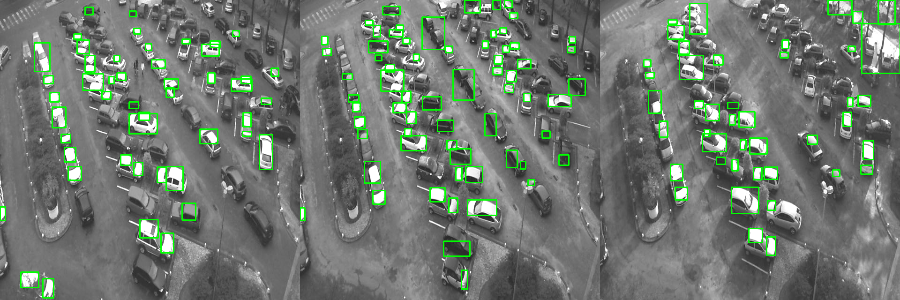

In [42]:
show_detections(res, num_samples=3)

# Conclusion et Perspectives
Cette approche de détection non supervisée démontre qu'il est possible d'isoler des éléments mobiles en exploitant la stabilité de l'arrière-plan au sein de groupes d'images cohérents (clusters). La combinaison du clustering par auto-encodeur et de la soustraction de fond médian permet d'extraire des informations pertinentes sans aucune phase d'étiquetage manuel préalable.

Toutefois, bien que les résultats soient encourageants, on observe un nombre important de faux positifs. Les ombres portées, les reflets sur la chaussée ou les changements brusques de contraste sont souvent interprétés à tort comme des véhicules par les algorithmes de traitement d'image classiques.

Pour rendre ce système réellement robuste et exploitable en conditions réelles, l'étape suivante consisterait à intégrer des méthodes supervisées. L'utilisation d'un modèle de Deep Learning (type YOLO ou SSD) permettrait de valider la nature de chaque objet détecté, garantissant ainsi que seules les voitures sont encadrées, tout en ignorant les bruits environnementaux.